# Entailment cones

In [2]:
import torch
import numpy as np
import geoopt
import torch.nn.functional as F

In [ ]:
# 8 points in the tangent space at the origin of the hyperboloid (in 2D)
x = torch.randn(8, 2)

# Adding 0's to first dimension to compute exponential map at origin (moving to ambient 3D space)
x_padded = F.pad(x, (1, 0, 0, 0)) 

# Curvature of the hyperboloid
k=torch.tensor([4.0])

# Moving points from the tangent space onto the hyperboloid with the exponential map
x_hyp = geoopt.manifolds.lorentz.math.expmap0(x_padded, k=k)

In [4]:
# Compute half apertures
half_apertures = geoopt.manifolds.lorentz.math.half_aperture(x_hyp, k)

### Visualization

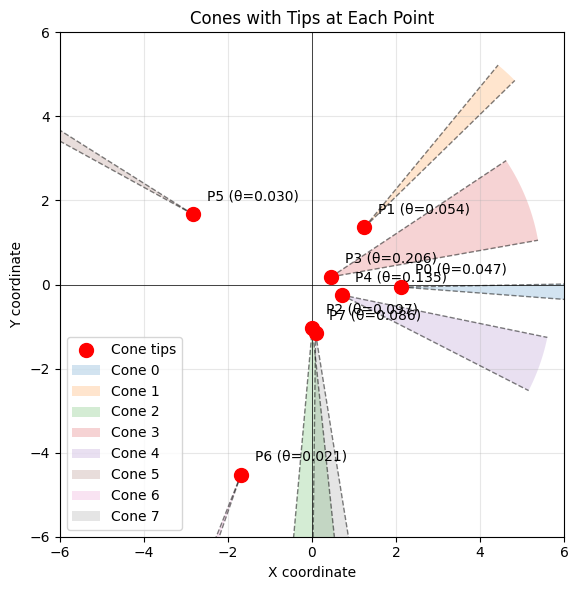

In [5]:
from matplotlib import pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

points = x_hyp.narrow(-1,1,2)

# Plot the points
x = points[:, 0].numpy()
y = points[:, 1].numpy()
ax.scatter(x, y, s=100, c='red', zorder=5, label='Cone tips')

# For each point, draw the cone
for i, (point, half_angle) in enumerate(zip(points, half_apertures)):
    # Direction from origin to point (this is the direction the cone opens)
    direction = point / torch.norm(point)
    
    # Angle of the central direction
    central_angle = torch.atan2(point[1], point[0])
    
    # Cone boundaries
    angle1 = central_angle - half_angle
    angle2 = central_angle + half_angle
    
    # Create the cone visualization
    # The cone starts at the point and extends outward
    extension_length = 5  # How far the cone extends from the tip
    
    # Generate the cone shape
    theta = torch.linspace(angle1, angle2, 50)
    
    # Draw filled cone
    vertices = [[point[0].item(), point[1].item()]]  # Start at the point (tip)
    for t in theta:
        # Extend from the point outward
        end_x = point[0].item() + extension_length * torch.cos(t).item()
        end_y = point[1].item() + extension_length * torch.sin(t).item()
        vertices.append([end_x, end_y])
    vertices.append([point[0].item(), point[1].item()])  # Close at tip
    
    vertices = np.array(vertices)
    ax.fill(vertices[:, 0], vertices[:, 1], alpha=0.2, label=f'Cone {i}')
    
    # Draw cone edges
    ax.plot([point[0].item(), point[0].item() + extension_length * np.cos(angle1.item())], 
            [point[1].item(), point[1].item() + extension_length * np.sin(angle1.item())], 
            'k--', linewidth=1, alpha=0.5)
    ax.plot([point[0].item(), point[0].item() + extension_length * np.cos(angle2.item())], 
            [point[1].item(), point[1].item() + extension_length * np.sin(angle2.item())], 
            'k--', linewidth=1, alpha=0.5)
    
    # Annotate the point
    ax.annotate(f'P{i} (θ={half_angle.item():.3f})', 
                (point[0].item(), point[1].item()),
                xytext=(10, 10), textcoords='offset points')

# Formatting
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title('Cones with Tips at Each Point')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_aspect('equal')
ax.legend()
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

plt.tight_layout()
plt.show()

Point: (-1.1083, -0.4231), Half aperture: 0.0844


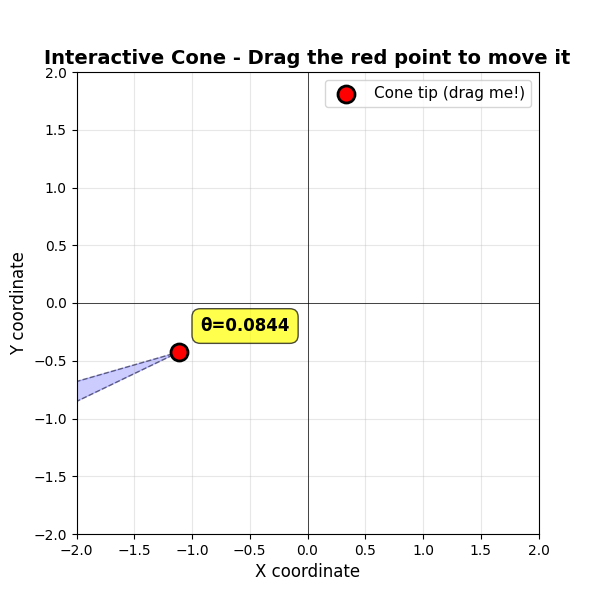

In [6]:
%matplotlib ipympl
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn.functional as F

class DraggableCone:
    def __init__(self, initial_x=-1.1083, initial_y=-0.4231):
        self.point = [initial_x, initial_y]
        self.dragging = False
        self.k = torch.tensor([4.0])
        
        # Create figure and axis
        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        
        # Initial plot
        self.update_plot()
        
        # Connect events
        self.fig.canvas.mpl_connect('button_press_event', self.on_press)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        
        plt.show()
    
    def update_plot(self):
        self.ax.clear()
        
        # Create tensor and compute half aperture
        points = torch.tensor([self.point])
        x_points = F.pad(points, (1, 0, 0, 0))
        half_apertures = geoopt.manifolds.lorentz.math.half_aperture(x_points, self.k)
        
        print(f"Point: ({self.point[0]:.4f}, {self.point[1]:.4f}), Half aperture: {half_apertures.item():.4f}")
        
        # Plot the point
        self.ax.scatter(self.point[0], self.point[1], s=150, c='red', 
                       zorder=5, label='Cone tip (drag me!)', edgecolors='black', linewidths=2)
        
        # Draw the cone
        point_tensor = points[0]
        half_angle = half_apertures[0]
        
        # Central angle
        central_angle = torch.atan2(point_tensor[1], point_tensor[0])
        
        # Cone boundaries
        angle1 = central_angle - half_angle
        angle2 = central_angle + half_angle
        
        # Extension length
        extension_length = 5
        
        # Generate the cone shape
        theta = torch.linspace(angle1, angle2, 50)
        
        # Draw filled cone
        vertices = [[point_tensor[0].item(), point_tensor[1].item()]]
        for t in theta:
            end_x = point_tensor[0].item() + extension_length * torch.cos(t).item()
            end_y = point_tensor[1].item() + extension_length * torch.sin(t).item()
            vertices.append([end_x, end_y])
        vertices.append([point_tensor[0].item(), point_tensor[1].item()])
        
        vertices = np.array(vertices)
        self.ax.fill(vertices[:, 0], vertices[:, 1], alpha=0.2, color='blue')
        
        # Draw cone edges
        self.ax.plot([point_tensor[0].item(), point_tensor[0].item() + extension_length * np.cos(angle1.item())], 
                [point_tensor[1].item(), point_tensor[1].item() + extension_length * np.sin(angle1.item())], 
                'k--', linewidth=1, alpha=0.5)
        self.ax.plot([point_tensor[0].item(), point_tensor[0].item() + extension_length * np.cos(angle2.item())], 
                [point_tensor[1].item(), point_tensor[1].item() + extension_length * np.sin(angle2.item())], 
                'k--', linewidth=1, alpha=0.5)
        
        # Annotate
        self.ax.annotate(f'θ={half_angle.item():.4f}', 
                    (point_tensor[0].item(), point_tensor[1].item()),
                    xytext=(15, 15), textcoords='offset points',
                    fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))
        
        # Formatting
        self.ax.set_xlabel('X coordinate', fontsize=12)
        self.ax.set_ylabel('Y coordinate', fontsize=12)
        self.ax.set_title('Interactive Cone - Drag the red point to move it', fontsize=14, fontweight='bold')
        self.ax.grid(True, alpha=0.3)
        self.ax.axhline(y=0, color='k', linewidth=0.5)
        self.ax.axvline(x=0, color='k', linewidth=0.5)
        self.ax.set_aspect('equal')
        self.ax.legend(fontsize=11)
        self.ax.set_xlim(-2, 2)
        self.ax.set_ylim(-2, 2)
        
        self.fig.canvas.draw_idle()
    
    def on_press(self, event):
        if event.inaxes != self.ax:
            return
        
        # Check if click is near the point
        dx = event.xdata - self.point[0]
        dy = event.ydata - self.point[1]
        distance = np.sqrt(dx**2 + dy**2)
        
        # If click is within 0.15 units of the point, start dragging
        if distance < 0.15:
            self.dragging = True
    
    def on_release(self, event):
        self.dragging = False
    
    def on_motion(self, event):
        if not self.dragging or event.inaxes != self.ax:
            return
        
        # Update point position
        self.point[0] = event.xdata
        self.point[1] = event.ydata
        
        # Redraw
        self.update_plot()

# Create the interactive plot
draggable = DraggableCone(initial_x=-1.1083, initial_y=-0.4231)